In [ ]:
from google.colab import files
uploaded=files.upload()

Saving archive.zip to archive (1).zip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
import zipfile

with zipfile.ZipFile("archive (1).zip", "r") as zip_ref:
    zip_ref.extractall(".")

In [ ]:
import os
print(os.listdir("."))

['.config', 'archive.zip', 'healthcare_data', '.ipynb_checkpoints', 'healthcare_dataset.csv', 'archive (1).zip', 'healthcare_dataset', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("healthcare_dataset.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [ ]:
df.shape

(55500, 15)

In [ ]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [ ]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [ ]:
df.isnull().sum()

,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


In [ ]:
df.duplicated().sum()

np.int64(534)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

In [ ]:
df['Length_of_Stay'] = (
    df['Discharge Date']
    - df['Date of Admission']
).dt.days

In [ ]:
df[['Date of Admission','Discharge Date','Length_of_Stay']].head()

,Date of Admission,Discharge Date,Length_of_Stay
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


In [ ]:
total_patients=len(df)
total_patients

54966

In [ ]:
df['Age'].mean()

np.float64(51.53518538733035)

In [ ]:
df['Billing Amount'].mean()

np.float64(25544.306284383965)

In [ ]:
df['Length_of_Stay'].mean()

np.float64(15.499290470472657)

In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,27496
Female,27470


In [ ]:
df['Medical Condition'].value_counts()

,count
Medical Condition,
Arthritis,9218
Diabetes,9216
Hypertension,9151
Obesity,9146
Cancer,9140
Asthma,9095


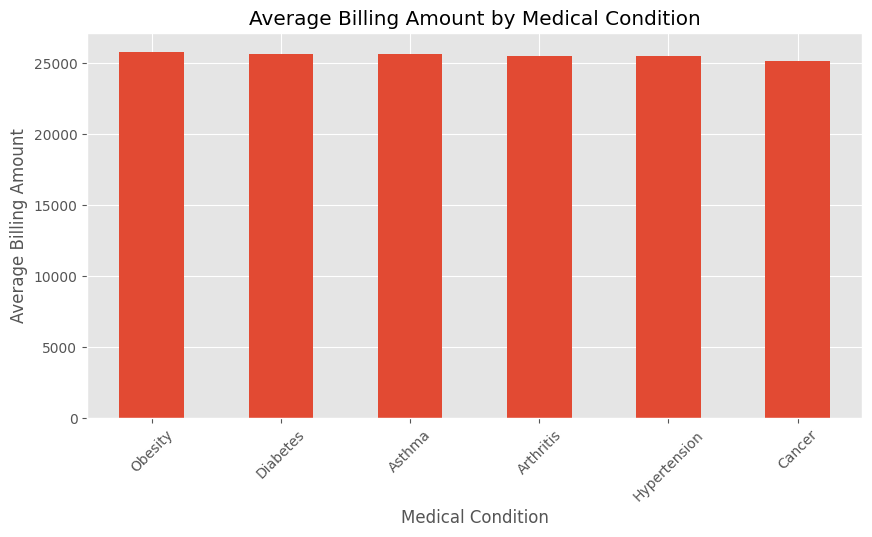

In [ ]:
avg_bill = df.groupby('Medical Condition')['Billing Amount'] \
             .mean() \
             .sort_values(ascending=False)

plt.figure(figsize=(10,5))
avg_bill.plot(kind='bar')

plt.title("Average Billing Amount by Medical Condition")
plt.ylabel("Average Billing Amount")
plt.xticks(rotation=45)

plt.show()

In [ ]:
df['Hospital'].nunique()

39876

In [ ]:
df['Doctor'].nunique()

40341

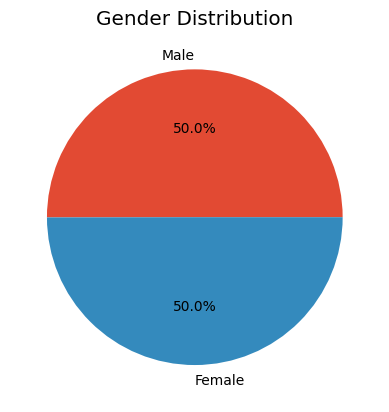

In [ ]:
df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title("Gender Distribution")
plt.show()

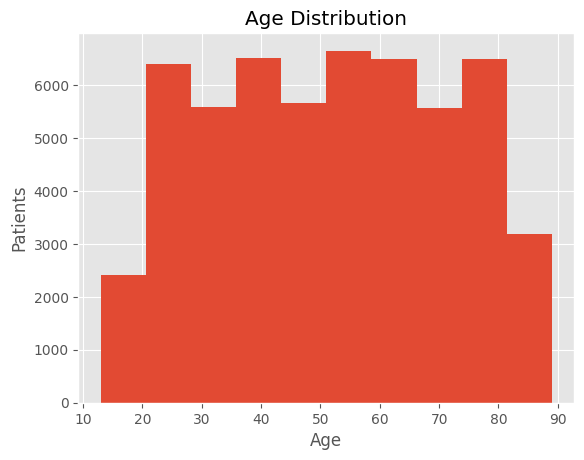

In [ ]:
plt.hist(df['Age'], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Patients")

plt.show()

In [ ]:
df.groupby('Hospital')['Billing Amount']\
.mean()\
.sort_values(ascending=False)\
.head(10)

,Billing Amount
Hospital,
Hernandez-Morton,52373.032374
Walker-Garcia,52170.036854
Ruiz-Anthony,52154.237722
George-Gonzalez,52102.240889
Rocha-Carter,52092.669896
"Briggs Walker Martinez, and",52024.726443
"and Small Stephens Harrington,",51975.968135
Clark-Espinoza,51848.201597
"Pierce and Miller James,",51722.122739


In [ ]:
df['Insurance Provider'].value_counts()

,count
Insurance Provider,
Cigna,11139
Medicare,11039
UnitedHealthcare,11014
Blue Cross,10952
Aetna,10822


In [ ]:
df['Admission Type'].value_counts()

,count
Admission Type,
Elective,18473
Urgent,18391
Emergency,18102


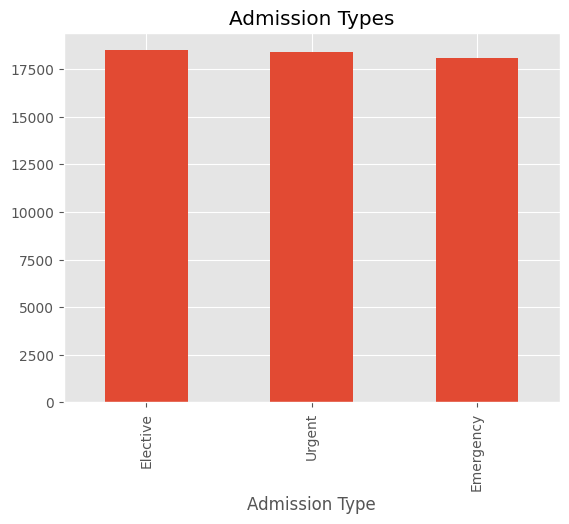

In [ ]:
df['Admission Type'].value_counts().plot(
    kind='bar'
)

plt.title("Admission Types")
plt.show()

In [ ]:
numeric_cols = [
    'Age',
    'Billing Amount',
    'Length_of_Stay'
]

corr = df[numeric_cols].corr()

corr

,Age,Billing Amount,Length_of_Stay
Age,1.000000,-0.003427,0.007890
Billing Amount,-0.003427,1.000000,-0.004891
Length_of_Stay,0.007890,-0.004891,1.000000


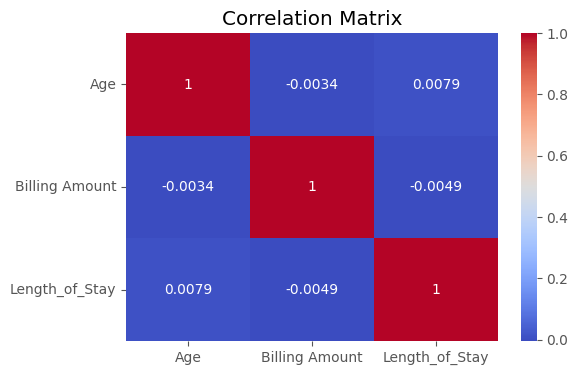

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
df.to_csv(
    "cleaned_healthcare_dataset.csv",
    index=False
)